# Поиск наилучшего узла

Узлов: 5514 Ребер: 12199
Расчет узлов


426923808 7.355415617070702


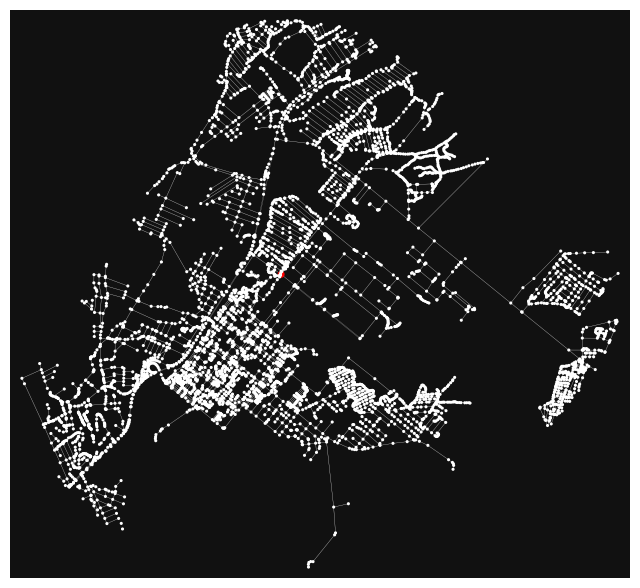

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl


G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

print('Расчет узлов')
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val = Graphs.get_best_node_full(G, 
                          node_metric_function=calc_node_metric_function
                          )
print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 5 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

## Расчет времени прибытия в каждый из узлов

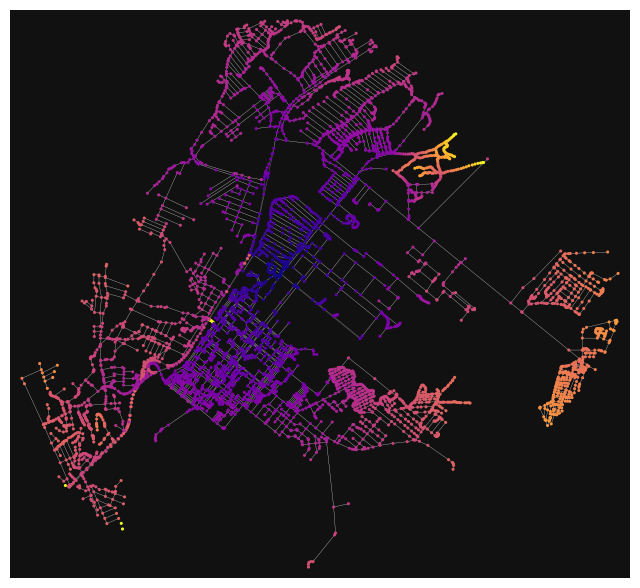

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
lens = ssfpl(G, best_node, weight = 'travel_time')
mval = max(lens.values())
lens_full = {node:lens[node] if node in lens else mval for node in G.nodes()}

nx.set_node_attributes(G, lens_full, 'route_time')
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=5)

## Расчет метрик во всех узлах

In [3]:
route_time_mean = {}
route_time_max = {}
nodes_ip5 = {}

i=0
for node in G.nodes():
    print(f'{i}/{G.number_of_nodes():<5}', end='\r')
    route_time_mean[node] = metric_by_time(G, 
                    path_function=msfpl,
                    metric_function=np.mean,
                    err_val=15)(node)
    route_time_max[node] = metric_by_time(G, 
                    path_function=msfpl, 
                    metric_function=np.max,
                    err_val=20)(node)
    nodes_ip5[node] = metric_by_time(G, 
                    path_function=msfpl, 
                    metric_function=cover_index(ip_val=5),
                    err_val=0)(node)
    i+=1

# Установка значений
nx.set_node_attributes(G, route_time_mean, 'route_time_mean')
nx.set_node_attributes(G, route_time_max, 'route_time_max')
nx.set_node_attributes(G, nodes_ip5, 'nodes_ip5')

# Печать карты со средними значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_mean", cmap="plasma")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с максимальными значениями
nc = ox.plot.get_node_colors_by_attr(G, attr="route_time_max", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

# Печать карты с значениями ИП-5
nc = ox.plot.get_node_colors_by_attr(G, attr="nodes_ip5", cmap="viridis")
ox.plot_graph(G, node_color=nc, edge_linewidth=0.3)

KeyboardInterrupt: 

## Поиск наилучшего узла из некоторого множества

In [10]:
nodes = list(G.nodes())
nodes_set = [nodes[50], nodes[200], nodes[500], nodes[1000], nodes[1500], nodes[3000], nodes[4000]]
print(nodes_set)
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val = Graphs.get_best_node_full(G, 
                          node_metric_function=calc_node_metric_function,
                          possible_nodes=nodes_set
                          )
print("лучший узел", best_node, best_val)

print('метрики для каждого из узлов:')
for node in nodes_set:
    m = calc_node_metric_function(node)
    print(node, m)

[426923800, 1526100295, 1555148534, 2034401706, 2034402276, 2760591335, 4901942432]


NameError: name 'msfpl' is not defined

## Расчет лучшего узла алгоритмом стока

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl

import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


426923808 7.355415617070702


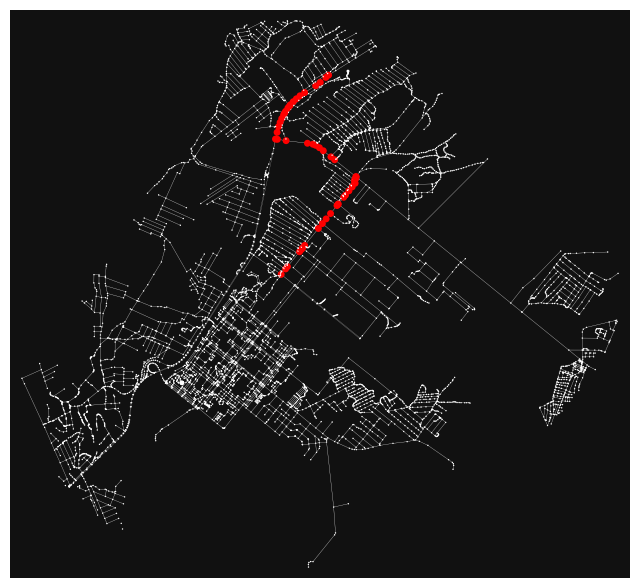

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# lg.basicConfig(level=lg.DEBUG)
# lg.basicConfig(level=lg.ERROR)
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function
                          )
# lg.basicConfig(level=lg.ERROR)

print(best_node, best_val)
nc = ['r' if nd in route else 'w' for nd in G.nodes()]
ns = [25 if nd in route else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

In [ ]:
calc_node_metric_function = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )
best_node, best_val, route = Graphs.get_best_node_drain(G, 
                          node_metric_function=calc_node_metric_function,
                          all_nodes=True
                          )

print(best_node, best_val)
# nc = ['r' if nd in route else 'w' for nd in G.nodes()]
# ns = [25 if nd in route else 5 for nd in G.nodes()]
# ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

426923808 7.355415617070702


## Расчет метрикой max_time+mean_time

In [2]:
def get_best_node_drain_mm(G, start_node=None):
    '''
    Это в калькуляторы

    Minimum travel time location problem - MTTLP
    '''
    calc_node_metric_function = metric_by_time(G,
                                path_function=msfpl,
                                metric_function=np.max,
                                )
    best_node, best_val, _ = Graphs.get_best_node_drain(G, 
                            node_metric_function=calc_node_metric_function,
                            start_node=start_node
                            )

    calc_node_metric_function = metric_by_time(G,
                                path_function=msfpl,
                                metric_function=np.mean,
                                )
    best_node, best_val, _ = Graphs.get_best_node_drain(G, 
                            node_metric_function=calc_node_metric_function,
                            start_node=best_node
                            )
    return best_node, best_val


print('Без стартового узла:', get_best_node_drain_mm(G))
node = 2712076294
print('Со стартовым узлом', get_best_node_drain_mm(G, node))

Без стартового узла: (426923808, 7.355415617070702)


Со стартовым узлом (426923808, 7.355415617070702)


С использованием функции из `algorithms.Graphs`

In [3]:
# Оценка для неизвестного стартового узла
cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, path_function=msfpl)
print('Оценка для неизвестного стартового узла', cur_node, cur_val)

# Оценка для известного стартового узла
cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, path_function=msfpl, start_node=list(G.nodes())[300])
print('Оценка для известного стартового узла', cur_node, cur_val)

Оценка для неизвестного стартового узла 426923808 7.355415617070702


TypeError: metric_by_time() got an unexpected keyword argument 'start_node'

### Расчет для нескольких узлов последовательно

С использованием функции из `algorithms.Graphs`

Расчет узла 2054468666
426923808 7.355415617070702
Расчет узла 4796091623
426923808 7.355415617070702
Расчет узла 4796070861
426923808 7.355415617070702
Расчет узла 2054468644
426923808 7.355415617070702
Расчет узла 2042076517
426923808 7.355415617070702
Расчет узла 9994288430
426923808 7.355415617070702
Расчет узла 2034401348
426923808 7.355415617070702
Расчет узла 9060052053
426923808 7.355415617070702
Расчет узла 3119947227
426923808 7.355415617070702
Расчет узла 4116052097
426923808 7.355415617070702
Расчет узла 2054469016
426923808 7.355415617070702
Расчет узла 2034402813
426923808 7.355415617070702
Расчет узла 4336348792
426923808 7.355415617070702
Расчет узла 2054468689
426923808 7.355415617070702
Расчет узла 2054469188
426923808 7.355415617070702
Расчет узла 3981428902
426923808 7.355415617070702
Расчет узла 3981463644
426923808 7.355415617070702
Расчет узла 4796070876
426923808 7.355415617070702
Расчет узла 4796091618
426923808 7.355415617070702
Расчет узла 2932152230
42692380

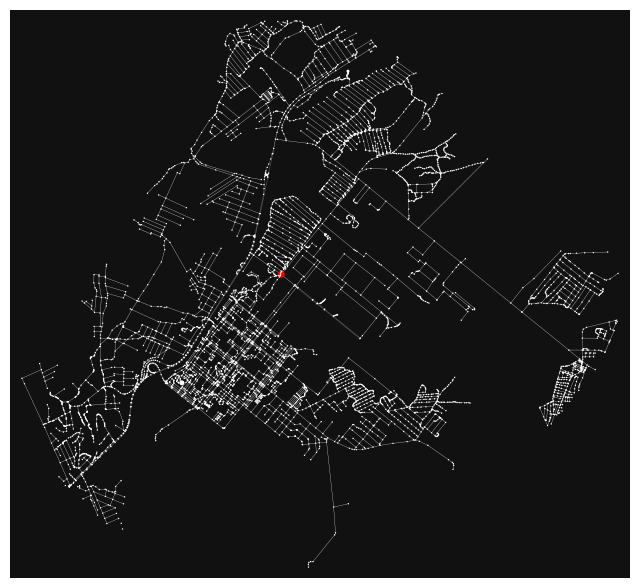

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
sample_size = 10
start_nodes = random.sample(list(G.nodes()), sample_size)
start_nodes

best_val = 1000
best_node
for node in start_nodes:
    print('Расчет узла', node)
    try:
        cur_node, cur_val = Graphs.get_best_node_drain_max_mean(G, node)
        print(cur_node, cur_val)
    except ValueError:
        print(f'Узел {node} неприемлем')                               
    if cur_val<best_val:
        best_val = cur_val
        best_node = cur_node

print(best_node, best_val)

nc = ['r' if nd==best_node else 'w' for nd in G.nodes()]
ns = [25 if nd==best_node else 1 for nd in G.nodes()]
ox.plot_graph(G, node_color=nc, edge_linewidth=0.2, node_size=ns)

# Расчет ячеек Вороного

In [2]:
import numpy as np
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl, msf

import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


In [ ]:
nodes_list = list(G.nodes())
centers = [nodes_list[20], nodes_list[200]]
print('центры', centers)
voronoi = nx.voronoi_cells(G, centers, weight='travel_time')
voronoi
# тупиковый путь - так как все-равно нужно добавлять функционал обрезки по границам

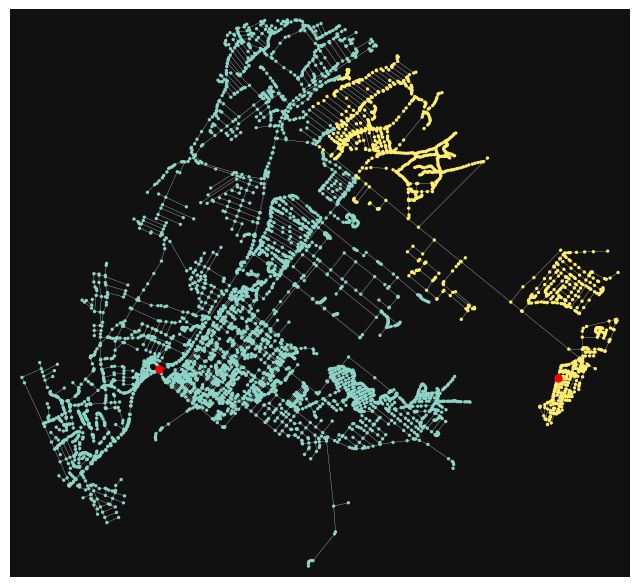

In [85]:
# Верный путь!
def calc_route_times(G:nx.MultiDiGraph,
                        sources:list|dict,
                        path_function,
                        weight: str = 'travel_time',
                        route_name = 'route_time',
                        nearest_name = 'nearest',
                        cutoff=None,
                        all_nodes_times=False,
                        all_nodes_pattern='node_{}'
                        ):

    # Проверка типов входящих данных
    if isinstance(sources, list):
        if isinstance(sources, list):
            if len(sources)==0:
                raise ValueError('В sources нет ни одного элемента!')
            for element in sources:
                if not isinstance(element, int):
                    raise TypeError("Все идентификаторы узлов в списке sources должны иметь тип данных int!")
                if not element in G.nodes():
                    raise KeyError(f"Узел {element} отсутствует в графе G")
    elif isinstance(sources, dict):
        if len(sources)==0:
            raise ValueError('В sources нет ни одного элемента!')
        for node, name in sources.items():
            if not isinstance(name, str):
                raise TypeError("Все имена узлов в словаре sources должны иметь тип данных str!")
            if not node in G.nodes():
                raise KeyError(f"Узел {node} отсутствует в графе G")
    else:
        raise TypeError("Идентификатор узла должен иметь тип данных int или list(int)!")
    if not isinstance(G, nx.MultiDiGraph):
        raise TypeError("Аргумент G должен иметь тип nx.MultiDiGraph!")

    # Расчет
    times, routes = path_function(G, sources=sources, cutoff=cutoff, weight=weight)
    times = pd.Series(times)
    if isinstance(sources, dict):
        nearest = pd.Series({k:sources[route[0]] for k, route in routes.items()}, dtype=str)
    else:
        nearest = pd.Series({k:route[0] for k, route in routes.items()}, dtype='int64')
    
    # Установка результатов расчета в качестве атрибутов ребер
    nx.set_node_attributes(G, times, route_name)
    nx.set_node_attributes(G, nearest, nearest_name)





nodes_list = list(G.nodes())
sources = {nodes_list[100]:'ПСЧ-1',
         nodes_list[2000]:'ПСЧ-22'}
# sources = [nodes_list[100], nodes_list[2000]]

calc_route_times(G, sources, nx.multi_source_dijkstra)

nds = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
# nds.plot(ax=ax, markersize=2, column='route_time')
nds.plot(ax=ax, markersize=2, column='nearest', cmap='Set3')
nds.loc[sources.keys()].plot(ax=ax, markersize=25, color='red')
plt.show()

In [87]:
# import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap  #, ListedColormap

colors = ["green", "yellow", "red"]
cmap1 = LinearSegmentedColormap.from_list("mycmap", colors)

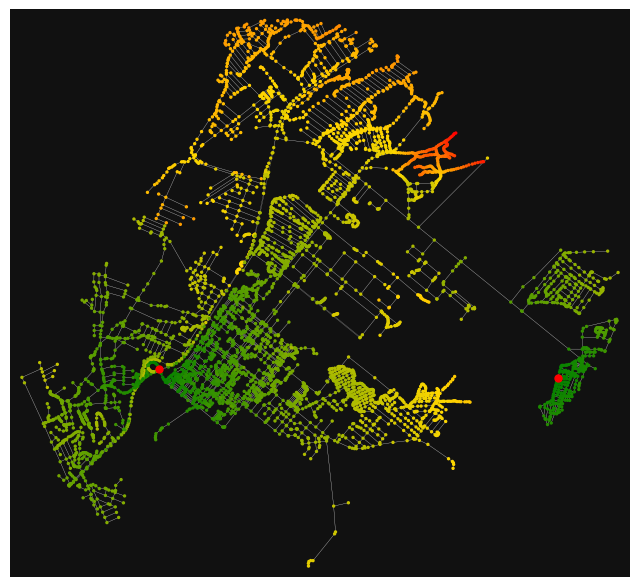

In [89]:
cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])

nds = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
nds.plot(ax=ax, markersize=2, column='route_time', cmap=cmap1)
# nds.plot(ax=ax, markersize=2, column='nearest')
nds.loc[sources.keys()].plot(ax=ax, markersize=25, color='red')
plt.show()

In [22]:
nds = ox.graph_to_gdfs(G, edges=False)
nds.query('nearest=="ПСЧ-1"')

,y,x,street_count,route_time,nearest,highway,geometry
osmid,,,,,,,


In [16]:
nds.query('nearest=="ПСЧ-22"')

,y,x,street_count,route_time,nearest,highway,geometry
osmid,,,,,,,
290700436,56.116593,93.309483,3,0.297886,ПСЧ-22,NaN,POINT (93.30948 56.11659)
290700439,56.116000,93.308877,2,0.428072,ПСЧ-22,NaN,POINT (93.30888 56.11600)
290700442,56.115449,93.308472,2,0.541536,ПСЧ-22,NaN,POINT (93.30847 56.11545)
290700445,56.114823,93.308154,2,0.665617,ПСЧ-22,NaN,POINT (93.30815 56.11482)
290700446,56.114246,93.307977,2,0.777279,ПСЧ-22,NaN,POINT (93.30798 56.11425)
...,...,...,...,...,...,...,...
10861562817,56.123782,93.301762,4,2.501880,ПСЧ-22,NaN,POINT (93.30176 56.12378)
10861562818,56.123778,93.302198,4,2.549609,ПСЧ-22,NaN,POINT (93.30220 56.12378)
10861562819,56.123544,93.304071,3,2.760424,ПСЧ-22,NaN,POINT (93.30407 56.12354)


С использованием функций из Graphs

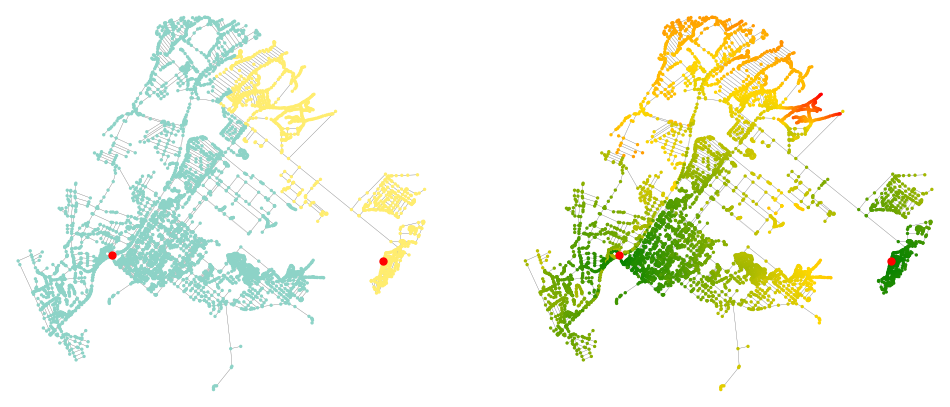

In [5]:
nodes_list = list(G.nodes())
sources = {nodes_list[100]:'ПСЧ-1',
         nodes_list[2000]:'ПСЧ-22'}

Graphs.calc_route_times_best_for_each(G, sources, msf)

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[sources.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
# nds = ox.graph_to_gdfs(G, edges=False)
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[sources.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

# Расчет для способа "от каждого узла к каждому узлу"

Проверка расчета для случая когда требуется рассчитать время прибытия из каждого стартового узла (мест размещения подразделений) в каждый узел графа. Пригодится для расчета по методике из СП 11.13130

In [3]:
import numpy as np
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap 

from genesis.algorithms import Graphs
# from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import ssfpl
from genesis.tools import Progressbar


import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


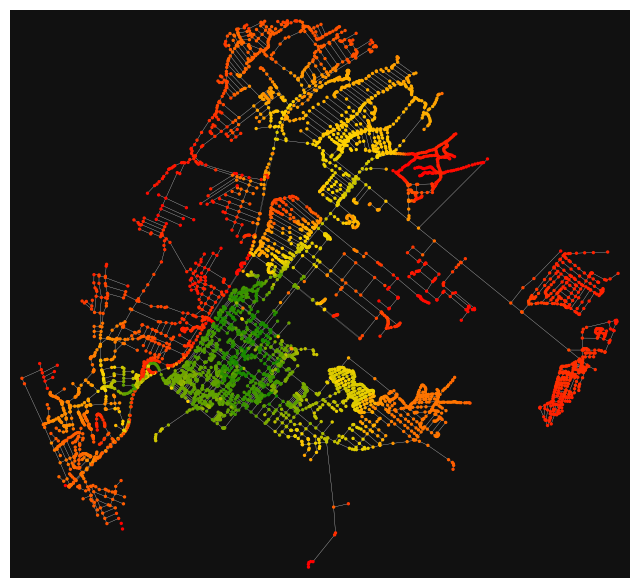

In [8]:
cutoff=5
sources= random.sample(list(G.nodes()), 100)

Graphs.calc_route_times_each_for_each(G, sources, path_function=ssfpl, 
                                      cutoff=cutoff,
                                      event_after_source_calc=Progressbar(len(sources), bins=50),
                                      cover_count_name='arrivals_count'
                                      )

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
cmap2 = LinearSegmentedColormap.from_list("mycmap", ["red", "gold", "green"])
nds = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False)
nds.plot(ax=ax, markersize=2, column='arrivals_count', cmap=cmap2)
plt.show()

In [9]:
# Отбор наилучшего узла
def metric_by_serie(nodes_arrivals):
    '''
    Функция определения метрики по заранее рассчитанной Series с временами прибытия из каждого из узлов
    '''
    def _metric_by_matrix(node):
        return len(nodes_arrivals.loc[node])
    return _metric_by_matrix

# Определение лучшего узла полным перебором по матрице
calc_node_metric_function = metric_by_serie(ox.graph_to_gdfs(G, edges=False)['routes_times'])
best_node, best_val = Graphs.get_best_node_full(G,
                    node_metric_function=calc_node_metric_function,
                    # event_after_node_calc=Progressbar(G.number_of_nodes()),
                    reduce=False
                    )
print(best_node, best_val)

[1998227467, 1998227475, 1998227477] 37


# Тесты

In [12]:
import numpy as np
import networkx as nx
import osmnx as ox

from genesis.algorithms import Graphs
from genesis.metrics import metric_by_time, cover_index
from genesis.swiss_knife import msfpl, ssfpl


In [39]:
def create_G():
    '''
        max: 21
        mean: 8.67
        median: 8.0
        ip-10: 66.67
        ip-20: 93.33
    '''
    G = nx.MultiDiGraph()
    G.add_edge(1, 2, key=0, travel_time=3)
    G.add_edge(1, 3, key=0, travel_time=2)
    G.add_edge(1, 4, key=0, travel_time=5)
    G.add_edge(2, 3, key=0, travel_time=2)
    G.add_edge(2, 5, key=0, travel_time=5)
    G.add_edge(2, 6, key=0, travel_time=7)
    G.add_edge(3, 2, key=0, travel_time=3)
    G.add_edge(3, 7, key=0, travel_time=3)
    G.add_edge(3, 8, key=0, travel_time=4)
    G.add_edge(3, 9, key=0, travel_time=5)
    G.add_edge(4, 3, key=0, travel_time=2)
    G.add_edge(4, 8, key=0, travel_time=4)
    G.add_edge(4, 10, key=0, travel_time=12)
    G.add_edge(4, 11, key=0, travel_time=10)
    G.add_edge(5, 8, key=0, travel_time=8)
    G.add_edge(5, 10, key=0, travel_time=8)
    G.add_edge(5, 12, key=0, travel_time=6)
    G.add_edge(5, 13, key=0, travel_time=9)
    G.add_edge(5, 12, key=0, travel_time=8)
    G.add_edge(6, 8, key=0, travel_time=1)
    G.add_edge(6, 9, key=0, travel_time=4)
    G.add_edge(6, 12, key=0, travel_time=4)
    G.add_edge(7, 10, key=0, travel_time=4)
    G.add_edge(7, 11, key=0, travel_time=9)
    G.add_edge(7, 13, key=0, travel_time=7)
    G.add_edge(8, 10, key=0, travel_time=6)
    G.add_edge(8, 13, key=0, travel_time=8)
    G.add_edge(9, 14, key=0, travel_time=10)
    G.add_edge(10, 13, key=0, travel_time=7)
    G.add_edge(10, 14, key=0, travel_time=5)
    G.add_edge(11, 12, key=0, travel_time=7)
    G.add_edge(11, 15, key=0, travel_time=7)
    G.add_edge(12, 13, key=0, travel_time=8)
    return G

def get_best_node_full(G:nx.MultiDiGraph,
                        node_metric_function=None,
                        possible_nodes=None,
                        reduce=True,
                        event_after_node_calc=None):
    '''
    Поиск лучшего узла полным перебором. 
    Могут быть возвращены только узлы из которых можно попасть в любой другой узел графа.
    Если таковых узлов нет, возвращается ошибка некорректности графа. 
    (граф должен быть проверен на корректность прежде чем будет передан функции)
    
    Узлы для которых метрика не может быть вычислена (например слабо связанные с основным графом) 
    не учитываются. 

    ## Важно
    Следует помнить, что некорректные узлы в случае их учета посредством снижения appr_val могут 
    давать искаженное представление о метриках графа. При этом в реальности граф дорожной сети 
    как правило изобилует слабосвязными узлами, поэтому учет только узлов обеспечивающих 100%
    достижимость всего графа может приводить к принципиальной невозможности расчета.

    ## Параметры
    `G` : MultiDiGraph
        Граф дорожной сети
    `path_function` : function
        Функция расчета пути вида nx.multi_source_dijkstra_path_length - расчет от множества узлов.
    `metric_function` : function
        Функция оценки. Если не указана, используется оценка по минимальному расстоянию.
    `weight` : str
        имя поля ребер ГДС содержащего вес пути (в данном случае имеется в виду время следования)
    `appr_val`: = 0.95
        Доля узлов графа, покрытие которой считается приемлемой для принятия расчетной метрики. 
        Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
        то такой узел не рассматривается.
    `possible_nodes`:list=None
        Если указано, то рассматриваются только переданные узлы.
    `reduce` : bool = True
        Если True - при сравнении значений метрик выбирается меньшее значение, иначе большее. 
        При расчете метрик для которых чем меньше значение тем лучше (среднее, максимальное время и т.д.) 
        необходимо использовать reduce=True, 
        при расчете метрик для которых чем больше тем лучше (ИП) - True

    ## Возвращает
    tuple: (list(int), float)
        Множестов - (идентификатор узла, значение метрики узла)
    '''
    if not isinstance(G, nx.MultiDiGraph):
        raise TypeError("Тип переменной G должен быть MultiDiGraph!")
    

    best_val = None
    best_node = None

    if not possible_nodes:
        possible_nodes = list(G.nodes())

    for node in possible_nodes:
        try:
            # Вычисление метрики для узла
            cur_val = node_metric_function(node)
            correct=True
        except ValueError:
            cur_val = best_val
            correct=False
        
        # Если узел приемлем (т.е. из него можно достичь приемлемое количество прочих узлов графа)
        if correct:
            # Если лучший узел еще не определен, устанавливаем его для текущего узла
            if best_val==None and not cur_val==None:
                best_val = cur_val
                best_node = []
            
            if not best_val==None and not cur_val==None:
                if cur_val==best_val:
                    best_node+=[node]
                if reduce and cur_val<best_val:
                    # Если требуется поиск наименьшей метрики
                    best_val = cur_val
                    best_node = [node]
                if not reduce and cur_val>best_val:
                    # Если требуется поиск наибольшей метрики
                    best_val = cur_val
                    best_node = [node]
        
        # Если указано событие которое должно происходить после расчета каждого узла - выполняем его
        if event_after_node_calc:
            event_after_node_calc()

    return best_node, best_val





G = create_G()
nodes_list=[2,5,8]

metric_function = metric_by_time(G, path_function=msfpl, metric_function=np.mean,
                     appr_val=0.1)
best_node, best_val = Graphs.get_best_nodes_full(G,
                        node_metric_function=metric_function
                        )
print(best_node, best_val)

# print('метрики для каждого из узлов:')
# for node in nodes_list:
#     m = metric_function(node)
#                     #  err_val='pass')
#     print(node, m)

[13, 14, 15] 0.0


# MCLP

## Решение пошагово

In [1]:
import numpy as np
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap 

from genesis.algorithms import Graphs
# from genesis.metrics import metric_by_time, cover_index
from genesis.metrics import metric_by_time
from genesis.swiss_knife import msf, msfpl   # ssfpl, msfpl, 
from genesis.tools import Progressbar


import random
# import logging as lg
# lg.basicConfig(level=lg.DEBUG)

G = ox.load_graphml('tests/data/test_rng.ml')
print("Узлов:", G.number_of_nodes(), "Ребер:",  G.number_of_edges())

Узлов: 5514 Ребер: 12199


In [18]:
def mclp_step_by_step(G:nx.MultiDiGraph, 
                            flex_locations,
                            calc_route_times_function,
                            best_node_function,
                            node_metric_function,
                            nearest_name = 'nearest',
                            epochs=5,
                            static_locations=None,
                            event_after_step_calc=None):
    '''
    Алгоритм решения задачи MCLP методом пошаговых приближений.
    '''

    if isinstance(flex_locations, list):
        flex_locations = {k:k for k in flex_locations}
    if isinstance(static_locations, list):
        static_locations = {k:k for k in static_locations}

    if isinstance(static_locations, dict):
        total_locations = {**flex_locations, **static_locations}
    else:
        total_locations = flex_locations
        static_locations = {}

    for i in range(epochs):
        print(f'epoch: {i}')
        m = metric_by_time(G,
                            path_function=msfpl,
                            metric_function=np.mean,
                            )(list(total_locations.keys()))
        print('Метрика:', m)
        # Расчет зон покрытия для каждого подразделения
        calc_route_times_function(G, 
            sources=total_locations,)
        
        # Развернем словарь для большего удобства использования
        temp_locations = {v:k for k,v in total_locations.items()}

        # Расчет лучшего размещения для каждой из зон 
        nodes = ox.graph_to_gdfs(G, edges=False)
        for k,v in temp_locations.items():
            if v not in static_locations.keys():
                nodes_for_location = nodes.query(f'`{nearest_name}` == "{k}"')
                g = G.subgraph(nodes_for_location.index)

                # Расчет лучшего узла
                best_node, best_val = best_node_function(G=g,
                                        start_node=v,
                                        node_metric_function=node_metric_function
                                        )
                print(k, best_val)
                temp_locations[k] = best_node
            else:
                print('static:', v, k)
        
        total_locations = {v:k for k,v in temp_locations.items()}
        print('='*80)

    return total_locations




# Тест
#==============================================================================
nodes_list = list(G.nodes())
sources = {nodes_list[100]:'ПСЧ-1',
         nodes_list[1000]:'ПСЧ-10',
         nodes_list[2000]:'ПСЧ-22'}
static = {nodes_list[200]:'ПСЧ-30'}


# Функция расчета метрик
nmf=metric_by_time(G,
                path_function=msfpl,
                metric_function=np.mean,
                )

# Обертка функции расчета лучшего узла
# def best_node_function_custom(G, start_node, node_metric_function):
#     return Graphs.get_best_node_drain(G=G,
#             node_metric_function=node_metric_function,
#             start_node=start_node
#         ) 
def best_node_function_custom(G, start_node, node_metric_function):
    return Graphs.get_best_node_drain_max_mean(G=G,
            path_function=msfpl,
            start_node=start_node
        )

# Обертка функции расчета времен прибытия в каждый узел от ближайшего источника
def calc_route_times_function_custom(G, sources):
    return Graphs.calc_route_times_best_for_each(G=G, 
                sources=sources,
                path_function=msf)



best_locations = mclp_step_by_step(G, 
    flex_locations=sources,
    calc_route_times_function=calc_route_times_function_custom,
    # best_node_function=Graphs.get_best_node_drain,
    best_node_function=best_node_function_custom,    
    node_metric_function=nmf, 
    static_locations=static)

epoch: 0
Метрика: 4.640522260563746
ПСЧ-1 3.2040910464285712
ПСЧ-10 4.8203301914817205
ПСЧ-22 2.437618948642266
static: 1526100295 ПСЧ-30
epoch: 1
Метрика: 3.8223748263340944
ПСЧ-1 3.355058953837223
ПСЧ-10 4.6819782668067225
ПСЧ-22 2.437618948642266
static: 1526100295 ПСЧ-30
epoch: 2
Метрика: 3.8171641058970094
ПСЧ-1 3.3587169310712754
ПСЧ-10 4.669077841424478
ПСЧ-22 2.6273293927170864
static: 1526100295 ПСЧ-30
epoch: 3
Метрика: 3.8171641058970094
ПСЧ-1 3.3587169310712754
ПСЧ-10 4.669077841424478
ПСЧ-22 2.6273293927170864
static: 1526100295 ПСЧ-30
epoch: 4
Метрика: 3.8171641058970094
ПСЧ-1 3.3587169310712754
ПСЧ-10 4.669077841424478
ПСЧ-22 2.6273293927170864
static: 1526100295 ПСЧ-30


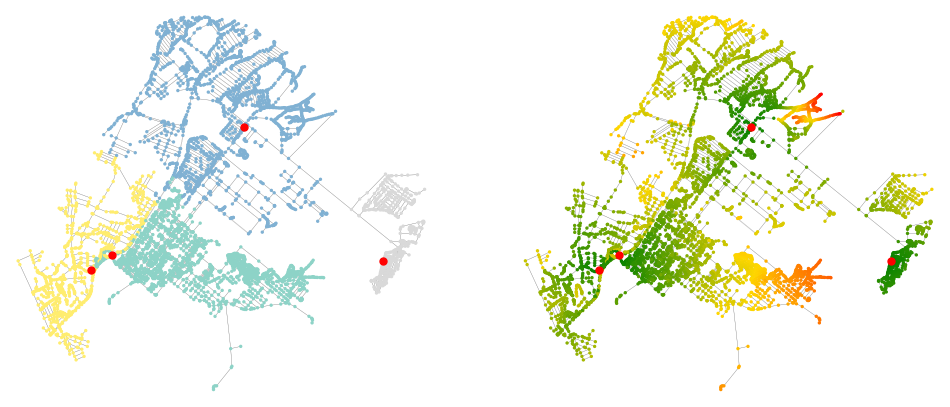

In [20]:
locations = {**sources, **static}
Graphs.calc_route_times_best_for_each(G, 
        sources=locations, 
        path_function=msf)

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()

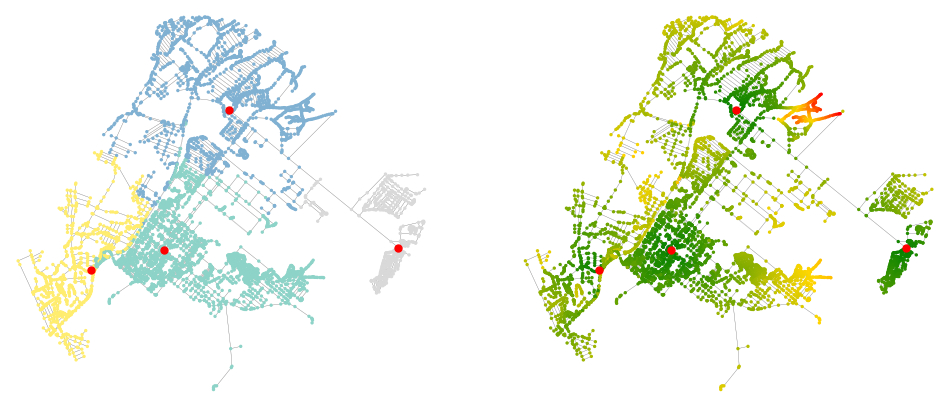

In [19]:
# best_locations_reverse = {v:k for k,v in best_locations.items()}
# best_locations_reverse = best_locations

Graphs.calc_route_times_best_for_each(G, 
        sources=best_locations, 
        path_function=msf)

nds = ox.graph_to_gdfs(G, edges=False)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax1)
nds.plot(ax=ax1, markersize=2, column='nearest', cmap='Set3')
nds.loc[best_locations.keys()].plot(ax=ax1, markersize=25, color='red')

cmap1 = LinearSegmentedColormap.from_list("mycmap", ["green", "gold", "red"])
ox.plot_graph(G, edge_linewidth=0.2, node_size=0, show=False, ax=ax2)
nds.plot(ax=ax2, markersize=2, column='route_time', cmap=cmap1)
nds.loc[best_locations.keys()].plot(ax=ax2, markersize=25, color='red')

plt.show()